In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance


In [3]:
df = pd.read_csv(
    "../data/processed/wearable_health_processed.csv"
)

In [4]:
X = df.drop(columns=["stress_class"])
y = df["stress_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [6]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [7]:
y_pred = model.predict(X_test)

In [8]:
print("Random Forest ")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Random Forest 
Accuracy: 0.6937852063902484

Classification Report:
              precision    recall  f1-score   support

        High       0.76      0.76      0.76      3488
         Low       0.76      0.78      0.77      3788
    Moderate       0.55      0.54      0.54      3553

    accuracy                           0.69     10829
   macro avg       0.69      0.69      0.69     10829
weighted avg       0.69      0.69      0.69     10829


Confusion Matrix:
[[2644   54  790]
 [  56 2950  782]
 [ 762  872 1919]]


Top 15 Features Affecting Stress Level
                  Feature  Importance
43          mood_very_bad    0.095785
16   sleep_duration_hours    0.095277
6            hrv_rmssd_ms    0.080929
13            caffeine_mg    0.059171
15        screen_time_min    0.052476
42           mood_neutral    0.041403
10                  steps    0.040970
14          alcohol_units    0.035445
17       sleep_efficiency    0.032610
11          calories_kcal    0.029533
20   sleep_stage_deep_pct    0.028319
21  sleep_stage_light_pct    0.027147
7            spo2_avg_pct    0.027078
9                dbp_mmHg    0.026880
8                sbp_mmHg    0.026846


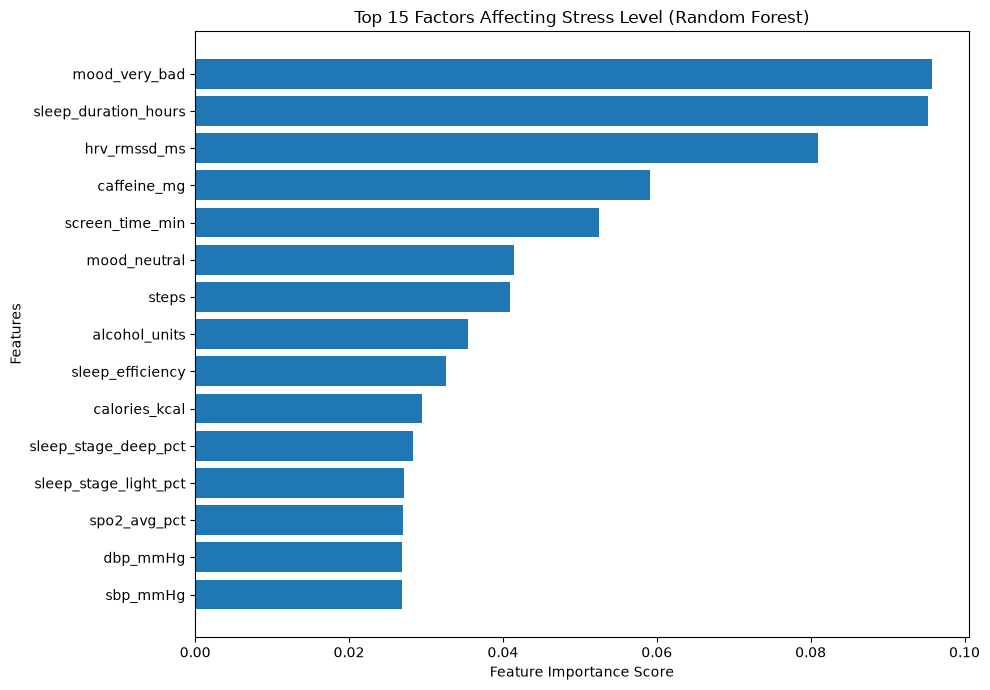

In [10]:
# RANDOM FOREST FEATURE IMPORTANCE



# Create dataframe of feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show top 15 features
top15_features = feature_importance.head(15)

print("Top 15 Features Affecting Stress Level")
print(top15_features)

# -------------------------
# Plot
# -------------------------

plt.figure(figsize=(10,7))

plt.barh(
    top15_features["Feature"],
    top15_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Factors Affecting Stress Level (Random Forest)")

plt.tight_layout()
plt.show()

In [13]:
# PERMUTATION FEATURE IMPORTANCE


# Calculate permutation importance on test data
perm_importance = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

# Convert into dataframe
permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean,
    "Std": perm_importance.importances_std
})

# Sort features
permutation_df = permutation_df.sort_values(
    by="Importance",
    ascending=False
)

# Top 15 features
top15_permutation = permutation_df.head(15)

print("Top 15 Permutation Feature Importance")
print(top15_permutation)

Top 15 Permutation Feature Importance
                      Feature  Importance       Std
43              mood_very_bad    0.058805  0.002649
6                hrv_rmssd_ms    0.048933  0.001803
13                caffeine_mg    0.034380  0.002197
15            screen_time_min    0.025506  0.001940
16       sleep_duration_hours    0.023234  0.003049
42               mood_neutral    0.022431  0.002174
41                  mood_good    0.012670  0.001359
14              alcohol_units    0.009484  0.001639
10                      steps    0.005264  0.001915
27  region_TR-EasternAnatolia    0.000822  0.000473
17           sleep_efficiency    0.000711  0.000913
33  device_model_SleepSense 2    0.000526  0.000445
35         workout_type_mixed    0.000397  0.000292
7                spo2_avg_pct    0.000397  0.001026
44             mood_very_good    0.000305  0.000295
